# Biodiversity 

In [1]:
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
import fiona
import os

### load data

In [2]:
data_dir = os.path.join(os.getcwd(), 'data')

# Path to the geodatabase
gdb_path = os.path.join(data_dir, 'Lebensraumkarte_v1_1_VD_20241025.gdb')

# List all layers in the geodatabase
layers = fiona.listlayers(gdb_path)

# Read a specific layer
areas = gpd.read_file(gdb_path, layer=layers[0])

bike_path = os.path.join(data_dir, 'lausanne_bike_edges.gpkg')
bike_roads = gpd.read_file(bike_path, columns=['POLYID', 'geometry'])

drive_path = os.path.join(data_dir, 'lausanne_drive_edges.gpkg')
drive_roads = gpd.read_file(drive_path, columns=['POLYID', 'geometry'])

walk_path = os.path.join(data_dir, 'lausanne_walk_edges.gpkg')
walk_roads = gpd.read_file(walk_path, columns=['POLYID', 'geometry'])

/home/quentin/Documents/bluecity-viz/.venv/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


### Regroup all road types

In [3]:
bike_roads["type"] = "bike"
drive_roads["type"] = "drive"
walk_roads["type"] = "walk"

roads = pd.concat([bike_roads, drive_roads, walk_roads], ignore_index=True)
roads = roads.head(1) # Limit to 10 rows for testing

### Select biodiversity areas within Lausanne

In [ ]:
buffer_distance = 10  # meters

# select only biodiversity areas within Lausanne
lausanne_boundary = gpd.read_file(os.path.join(data_dir, 'Lausanne Districts.gpkg'), columns=['geometry'])
lausanne_boundary["geometry"] = lausanne_boundary.geometry.buffer(buffer_distance)  # includes outside areas that are close to the boundary
xmin, ymin, xmax, ymax = lausanne_boundary.total_bounds

areas_lausanne = areas.cx[xmin:xmax, ymin:ymax]
areas_lausanne = areas_lausanne[~areas_lausanne["TypoCH"].str.startswith("9")] # Zones spéciales
areas_lausanne = areas_lausanne[~areas_lausanne["TypoCH"].str.startswith("8")] # Zones de trasport
areas_lausanne = areas_lausanne[~areas_lausanne["TypoCH"].str.startswith("5")] # Surfaces bâties

### Find biodiversity areas within a certain buffer distance of roads

In [33]:
# Ensure same CRS by reprojecting roads to match areas_lausanne
roads = roads.to_crs(areas_lausanne.crs)

# Create a buffered version of roads without modifying the original
roads_buffered = roads.copy()
roads_buffered['geometry'] = roads_buffered.geometry.buffer(buffer_distance)

# Spatial join to find biodiversity areas within each buffered road
# Each road will have multiple rows if it intersects multiple areas
roads_with_biodiversity = gpd.sjoin(areas_lausanne, roads_buffered, how='left', predicate='intersects')
roads_with_biodiversity['cluster'] = None

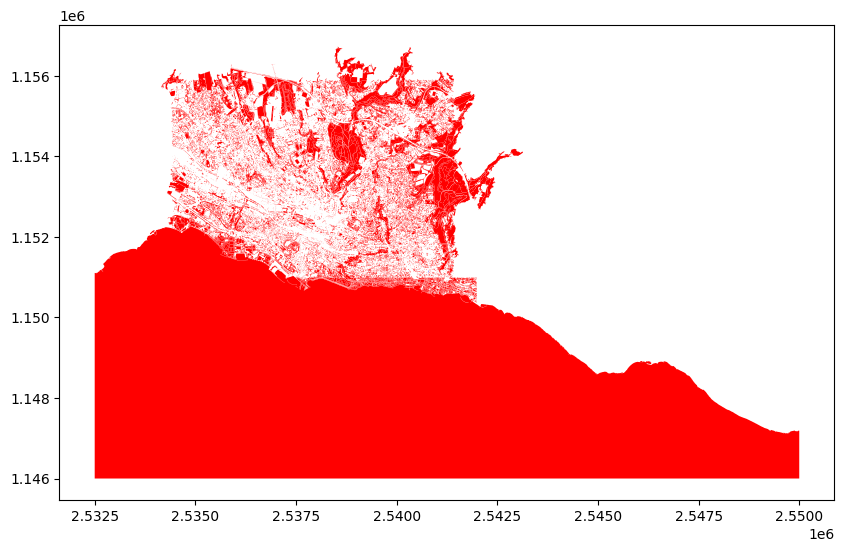

In [34]:
fig, ax = plt.subplots(figsize=(10, 10))
roads.plot(ax=ax, color='blue', markersize=5)
roads_with_biodiversity.plot(ax=ax, color='red', markersize=1)
plt.show()